In [1]:
PCOS detection Using ultrasound images.

In [2]:
import tensorflow as tf

In [ ]:
directory= '../input/pcos-detection-using-ultrasound-images/data/train'

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image_dataset_from_directory
import cv2
import numpy as np
import os
import pandas as pd

In [ ]:
train_ds=tf.keras.preprocessing.image_dataset_from_directory(
    directory,
    labels="inferred",
    label_mode="binary",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    seed=24,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=True,
    crop_to_aspect_ratio=False,
)

Found 1924 files belonging to 2 classes.


2022-04-12 12:46:14.965999: I tensorflow/core/common_runtime/process_util.cc:146] Creating new thread pool with default inter op setting: 2. Tune using inter_op_parallelism_threads for best performance.


2022-04-12 12:46:15.182058: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


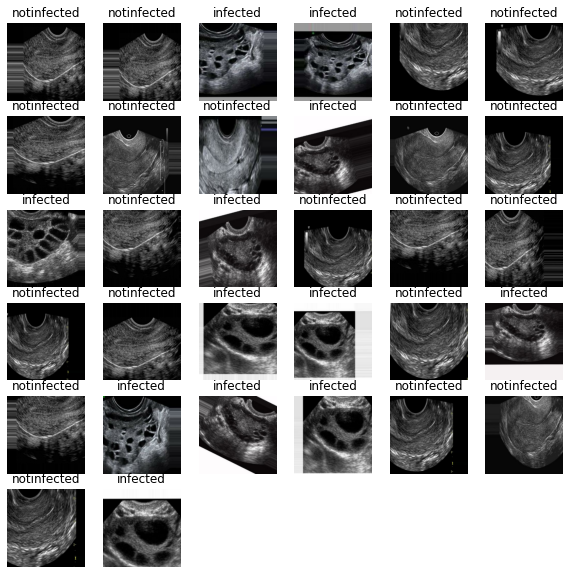

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
class_names = train_ds.class_names
for images, labels in train_ds.take(2):
    for i in range(32):
        ax = plt.subplot(6, 6, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")

Augumentation


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# create generator
datagen = ImageDataGenerator(rescale = 1./255,
                             shear_range = 0.2,
                             zoom_range = 0.2,
                             horizontal_flip = True,
                             vertical_flip=True,
                             rotation_range=30,
                             validation_split=0.3,
                             fill_mode='nearest'
                             )
# prepare an iterators for each dataset
train_it = datagen.flow_from_directory( directory,
                                       class_mode='categorical',
                                       classes=['infected', 'notinfected'],
                                       target_size=(224, 224),
                                       batch_size=100,
                                       subset='training',
                                       seed=24)
# prepare an iterators for each dataset
val_it = datagen.flow_from_directory( directory,
                                       class_mode='categorical',
                                       classes=['infected', 'notinfected'],
                                       target_size=(224, 224),
                                       batch_size=100,
                                       subset='validation',
                                       seed=24)

Found 1348 images belonging to 2 classes.
Found 576 images belonging to 2 classes.


In [ ]:
batchX, batchy = train_it.next()
print('Batch shape=%s, min=%.3f, max=%.3f' % (batchy.shape, batchy.min(), batchy.max()))
print('Batch shape=%s, min=%.3f, max=%.3f' % (batchX.shape, batchX.min(), batchX.max()))

Batch shape=(100, 2), min=0.000, max=1.000
Batch shape=(100, 224, 224, 3), min=0.000, max=1.000


In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras import Sequential

# Model 1

In [ ]:
model1 = Sequential()
model1.add(Conv2D(10, (5,5),padding='valid',activation='relu',input_shape=(224,224,3)))
model1.add(MaxPooling2D(pool_size=(4,4)))
# REPEAT CONV AND POOLING layer 3 TIMES
model1.add(Conv2D(12, (5,5),padding='valid',activation='relu'))
model1.add(MaxPooling2D(pool_size=(4,4)))
#model1.add(Conv2D(128, (5,5),padding='valid',activation='relu'))
# model1.add(Conv2D(256, (5,5),padding='valid',activation='relu'))
# model1.add(MaxPooling2D(pool_size=(4,4)))
model1.add(Flatten())
#model1.add(Dense(128,activation='relu'))
#model1.add(Dense(64,activation='relu'))
model1.add(Dense(2,activation='softmax'))

In [ ]:
model1.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 220, 220, 10)      760       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 55, 55, 10)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 51, 51, 12)        3012      
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 12, 12, 12)        0         
_________________________________________________________________
flatten (Flatten)            (None, 1728)              0         
_________________________________________________________________
dense (Dense)                (None, 2)                 3458      
Total params: 7,230
Trainable params: 7,230
Non-trainable params: 0
______________________________________________________

In [ ]:
from tensorflow.keras.losses import CategoricalCrossentropy
model1.compile(
  optimizer='adam',
  loss=CategoricalCrossentropy(),
  metrics=['accuracy'])

In [ ]:
history = model1.fit(
  train_it,
  validation_data=val_it,
  epochs=5)

Epoch 1/5
14/14 [==============================] - 43s 3s/step - loss: 0.5985 - accuracy: 0.7144 - val_loss: 0.4592 - val_accuracy: 0.8073
Epoch 2/5
14/14 [==============================] - 37s 3s/step - loss: 0.4080 - accuracy: 0.8264 - val_loss: 0.3854 - val_accuracy: 0.8385
Epoch 3/5
14/14 [==============================] - 37s 3s/step - loss: 0.3368 - accuracy: 0.8464 - val_loss: 0.2765 - val_accuracy: 0.8819
Epoch 4/5
14/14 [==============================] - 37s 3s/step - loss: 0.2540 - accuracy: 0.9058 - val_loss: 0.1984 - val_accuracy: 0.9288
Epoch 5/5
14/14 [==============================] - 36s 3s/step - loss: 0.1866 - accuracy: 0.9332 - val_loss: 0.1465 - val_accuracy: 0.9410


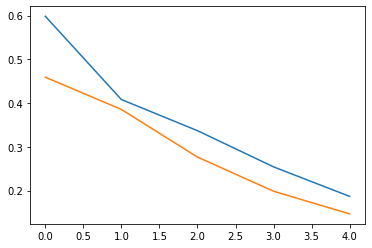

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

# Model 2

final model

In [ ]:
model2 = Sequential()
model2.add(Conv2D(12, (6,6),padding='valid',activation='relu',input_shape=(224,224,3)))
model2.add(MaxPooling2D(pool_size=(6,6)))
model2.add(Conv2D(15, (5,5),padding='valid',activation='relu'))
model2.add(MaxPooling2D(pool_size=(5,5)))
model2.add(Conv2D(10, (3,3),padding='valid',activation='relu'))
# model2.add(Conv2D(256, (5,5),padding='valid',activation='relu'))
model2.add(MaxPooling2D(pool_size=(3,3)))
model2.add(Flatten())
#model2.add(Dense(128,activation='relu'))
#model2.add(Dense(64,activation='relu'))
model2.add(Dense(2,activation='softmax'))

In [ ]:
from tensorflow.keras.losses import CategoricalCrossentropy
model2.compile(
  optimizer='adam',
  loss=CategoricalCrossentropy(),
  metrics=['accuracy'])

In [ ]:
history = model2.fit(
  train_it,
  validation_data=val_it,
  epochs=8)

Epoch 1/8
14/14 [==============================] - 39s 3s/step - loss: 0.6464 - accuracy: 0.6276 - val_loss: 0.5989 - val_accuracy: 0.7795
Epoch 2/8
14/14 [==============================] - 36s 3s/step - loss: 0.5402 - accuracy: 0.8093 - val_loss: 0.4469 - val_accuracy: 0.8507
Epoch 3/8
14/14 [==============================] - 36s 3s/step - loss: 0.3826 - accuracy: 0.8769 - val_loss: 0.2795 - val_accuracy: 0.9462
Epoch 4/8
14/14 [==============================] - 36s 3s/step - loss: 0.2291 - accuracy: 0.9570 - val_loss: 0.1573 - val_accuracy: 0.9740
Epoch 5/8
14/14 [==============================] - 36s 3s/step - loss: 0.1489 - accuracy: 0.9577 - val_loss: 0.1351 - val_accuracy: 0.9653
Epoch 6/8
14/14 [==============================] - 36s 3s/step - loss: 0.1237 - accuracy: 0.9629 - val_loss: 0.0757 - val_accuracy: 0.9844
Epoch 7/8
14/14 [==============================] - 37s 3s/step - loss: 0.0890 - accuracy: 0.9785 - val_loss: 0.0736 - val_accuracy: 0.9826
Epoch 8/8
14/14 [==========

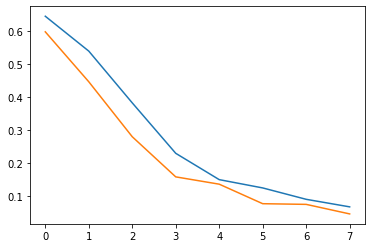

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

# Model 3


In [ ]:
model3 = Sequential()
model3.add(Conv2D(10, (5,5),padding='valid',activation='relu',input_shape=(224,224,3)))
model3.add(MaxPooling2D(pool_size=(4,4)))
model3.add(Conv2D(12, (5,5),padding='valid',activation='relu'))
model3.add(MaxPooling2D(pool_size=(4,4)))
model3.add(Conv2D(5, (3,3),padding='valid',activation='relu'))
# model3.add(Conv2D(256, (5,5),padding='valid',activation='relu'))
model3.add(MaxPooling2D(pool_size=(3,3)))
model3.add(Flatten())
#model3.add(Dense(128,activation='relu'))
#model3.add(Dense(64,activation='relu'))
model3.add(Dense(2,activation='softmax'))

In [ ]:
from tensorflow.keras.losses import CategoricalCrossentropy
model3.compile(
  optimizer='adam',
  loss=CategoricalCrossentropy(),
  metrics=['accuracy'])

In [ ]:
history = model3.fit(
  train_it,
  validation_data=val_it,
  epochs=6)

Epoch 1/6
14/14 [==============================] - 39s 3s/step - loss: 0.6702 - accuracy: 0.6061 - val_loss: 0.6215 - val_accuracy: 0.7830
Epoch 2/6
14/14 [==============================] - 37s 3s/step - loss: 0.5696 - accuracy: 0.7782 - val_loss: 0.4823 - val_accuracy: 0.8090
Epoch 3/6
14/14 [==============================] - 36s 3s/step - loss: 0.4312 - accuracy: 0.8034 - val_loss: 0.3439 - val_accuracy: 0.8646
Epoch 4/6
14/14 [==============================] - 36s 3s/step - loss: 0.3338 - accuracy: 0.8531 - val_loss: 0.2925 - val_accuracy: 0.8854
Epoch 5/6
14/14 [==============================] - 36s 3s/step - loss: 0.2534 - accuracy: 0.8895 - val_loss: 0.2187 - val_accuracy: 0.9115
Epoch 6/6
14/14 [==============================] - 36s 3s/step - loss: 0.2100 - accuracy: 0.9125 - val_loss: 0.1856 - val_accuracy: 0.9323


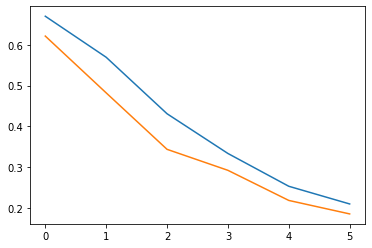

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

# Model 4

In [ ]:
model4 = Sequential()
model4.add(Conv2D(12, (5,5),padding='valid',activation='relu',input_shape=(224,224,3)))
model4.add(MaxPooling2D(pool_size=(4,4)))
model4.add(Conv2D(10, (5,5),padding='valid',activation='relu'))
model4.add(MaxPooling2D(pool_size=(4,4)))
model4.add(Conv2D(8, (3,3),padding='valid',activation='relu'))
# model4.add(Conv2D(256, (5,5),padding='valid',activation='relu'))
model4.add(MaxPooling2D(pool_size=(3,3)))
model4.add(Flatten())
#model4.add(Dense(128,activation='relu'))
#model4.add(Dense(64,activation='relu'))
model4.add(Dense(2,activation='softmax'))

In [ ]:
from tensorflow.keras.losses import CategoricalCrossentropy
model4.compile(
  optimizer='adam',
  loss=CategoricalCrossentropy(),
  metrics=['accuracy'])

In [ ]:
history = model4.fit(
  train_it,
  validation_data=val_it,
  epochs=10)

Epoch 1/10
14/14 [==============================] - 38s 3s/step - loss: 0.6811 - accuracy: 0.5697 - val_loss: 0.6558 - val_accuracy: 0.5938
Epoch 2/10
14/14 [==============================] - 36s 3s/step - loss: 0.6320 - accuracy: 0.6402 - val_loss: 0.5836 - val_accuracy: 0.7882
Epoch 3/10
14/14 [==============================] - 37s 3s/step - loss: 0.4994 - accuracy: 0.8628 - val_loss: 0.3934 - val_accuracy: 0.9045
Epoch 4/10
14/14 [==============================] - 36s 3s/step - loss: 0.2848 - accuracy: 0.9340 - val_loss: 0.2054 - val_accuracy: 0.9236
Epoch 5/10
14/14 [==============================] - 37s 3s/step - loss: 0.1583 - accuracy: 0.9562 - val_loss: 0.1073 - val_accuracy: 0.9757
Epoch 6/10
14/14 [==============================] - 37s 3s/step - loss: 0.0871 - accuracy: 0.9770 - val_loss: 0.0937 - val_accuracy: 0.9740
Epoch 7/10
14/14 [==============================] - 36s 3s/step - loss: 0.0644 - accuracy: 0.9829 - val_loss: 0.0722 - val_accuracy: 0.9740
Epoch 8/10
14/14 [==

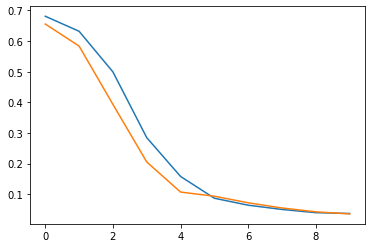

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

# Model 5

In [ ]:
model5 = Sequential()
model5.add(Conv2D(15, (5,5),padding='valid',activation='relu',input_shape=(224,224,3)))
model5.add(MaxPooling2D(pool_size=(5,5)))
model5.add(Conv2D(12, (4,4),padding='valid',activation='relu'))
model5.add(MaxPooling2D(pool_size=(4,4)))
model5.add(Conv2D(8, (3,3),padding='valid',activation='relu'))
# model5.add(Conv2D(256, (5,5),padding='valid',activation='relu'))
model5.add(MaxPooling2D(pool_size=(3,3)))
model5.add(Flatten())
#model5.add(Dense(128,activation='relu'))
#model5.add(Dense(64,activation='relu'))
model5.add(Dense(2,activation='softmax'))

In [ ]:
from tensorflow.keras.losses import CategoricalCrossentropy
model5.compile(
  optimizer='adam',
  loss=CategoricalCrossentropy(),
  metrics=['accuracy'])

In [ ]:
history = model5.fit(
  train_it,
  validation_data=val_it,
  epochs=7)

Epoch 1/7
14/14 [==============================] - 38s 3s/step - loss: 0.6613 - accuracy: 0.6150 - val_loss: 0.6292 - val_accuracy: 0.6528
Epoch 2/7
14/14 [==============================] - 36s 3s/step - loss: 0.5861 - accuracy: 0.7196 - val_loss: 0.5200 - val_accuracy: 0.7986
Epoch 3/7
14/14 [==============================] - 36s 3s/step - loss: 0.4596 - accuracy: 0.8168 - val_loss: 0.3910 - val_accuracy: 0.8385
Epoch 4/7
14/14 [==============================] - 36s 3s/step - loss: 0.3214 - accuracy: 0.8865 - val_loss: 0.2406 - val_accuracy: 0.9306
Epoch 5/7
14/14 [==============================] - 36s 3s/step - loss: 0.2141 - accuracy: 0.9407 - val_loss: 0.1840 - val_accuracy: 0.9323
Epoch 6/7
14/14 [==============================] - 36s 3s/step - loss: 0.1306 - accuracy: 0.9607 - val_loss: 0.1245 - val_accuracy: 0.9635
Epoch 7/7
14/14 [==============================] - 37s 3s/step - loss: 0.0872 - accuracy: 0.9711 - val_loss: 0.0888 - val_accuracy: 0.9705


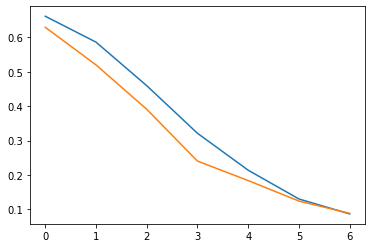

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

# Saving Model

In [ ]:
model2.save('model.h5')

In [ ]:
from tensorflow import keras
model = keras.models.load_model('model.h5')

In [ ]:

from keras.preprocessing.image import load_img
image = load_img('../input/pcos-detection-using-ultrasound-images/data/test/infected/img1.jpg', target_size=(224, 224))
img = np.array(image)
img = img / 255.0
img = img.reshape(1,224,224,3)
prediction = model.predict(img)

In [ ]:
type(prediction)

numpy.ndarray

In [ ]:
print(prediction)

[[0.64568764 0.35431233]]


In [ ]:
l={"infected":prediction[0][0],"notinfected":prediction[0][1]}
def get_key(val):
    for key, value in l.items():
         if val == value:
             return key

    return "key doesn't exist"
#label[0][1]

In [ ]:
j=prediction.max()
get_key(j)

'infected'